# Cross-Dataset NILM Evaluation & Metric Visualization

This notebook handles the evaluation of NILM disaggregation models, compares baseline vs improved models, and visualizes classification and energy error metrics.

In [30]:
import os
import sys
import json
import shutil
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('.'))
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


### Step 1: Run Baseline and Improved Evaluations
This cell executes the evaluation CLI twice to gather metrics for the baseline model (reverted via Git) and the improved model (using Bayesian adaptation).

In [31]:
root_dir = os.path.abspath('.')
fhmm_path = os.path.join(root_dir, 'services/fhmm_service.py')
sigs_path = os.path.join(root_dir, 'data/appliance_signatures.json')

fhmm_bak = fhmm_path + '.bak'
sigs_bak = sigs_path + '.bak'

shutil.copyfile(fhmm_path, fhmm_bak)
shutil.copyfile(sigs_path, sigs_bak)

try:
    # Clear stale profile to prevent cross-dataset adaptation contamination
    profile_path = os.path.join(root_dir, 'data/user_profiles/refit_user_adaptation.json')
    if os.path.exists(profile_path):
        os.remove(profile_path)
    
    print("Reverting to baseline via git...")
    subprocess.run(['git', 'checkout', 'HEAD', '--', 'services/fhmm_service.py', 'data/appliance_signatures.json'], cwd=root_dir, check=True)
    
    print("Running baseline evaluation...")
    cmd_base = [
        'python', 'evaluation/cross_dataset.py',
        '--consolidated-csv', 'data/CLEAN_House21.csv',
        '--appliance-map', 'Kettle=Appliance3',
        '--max-rows', '20000',
        '--output-report', 'evaluation/baseline_report.json'
    ]
    subprocess.run(cmd_base, cwd=root_dir, capture_output=True, text=True, check=True)
    
    print("Restoring improved code...")
    shutil.copyfile(fhmm_bak, fhmm_path)
    shutil.copyfile(sigs_bak, sigs_path)
    
    print("Running improved evaluation with Bayesian adaptation (Pass 1)...")
    cmd_impr = [
        'python', 'evaluation/cross_dataset.py',
        '--consolidated-csv', 'data/CLEAN_House21.csv',
        '--appliance-map', 'Kettle=Appliance3',
        '--max-rows', '20000',
        '--user-id', 'refit_user_adaptation',
        '--output-report', 'evaluation/improved_report.json'
    ]
    subprocess.run(cmd_impr, cwd=root_dir, capture_output=True, text=True, check=True)
    
    print("Running improved evaluation with Bayesian adaptation (Pass 2)...")
    subprocess.run(cmd_impr, cwd=root_dir, capture_output=True, text=True, check=True)
    
finally:
    if os.path.exists(fhmm_bak):
        shutil.copyfile(fhmm_bak, fhmm_path)
        os.remove(fhmm_bak)
    if os.path.exists(sigs_bak):
        shutil.copyfile(sigs_bak, sigs_path)
        os.remove(sigs_bak)

print("Evaluation complete.")

Reverting to baseline via git...
Running baseline evaluation...
Restoring improved code...
Running improved evaluation with Bayesian adaptation (Pass 1)...
Running improved evaluation with Bayesian adaptation (Pass 2)...
Evaluation complete.


### Step 2: Load and Display Metric Results

In [32]:
with open('evaluation/baseline_report.json') as f:
    base_data = json.load(f)['Kettle']
with open('evaluation/improved_report.json') as f:
    impr_data = json.load(f)['Kettle']

metrics_df = pd.DataFrame({
    'Metric': ['F1-Score', 'Precision', 'Recall', 'SAE', 'MAE (W)'],
    'Baseline': [base_data['F1-Score'], base_data['Precision'], base_data['Recall'], base_data['SAE'], base_data['MAE (W)']],
    'Improved': [impr_data['F1-Score'], impr_data['Precision'], impr_data['Recall'], impr_data['SAE'], impr_data['MAE (W)']]
})
metrics_df

,Metric,Baseline,Improved
0,F1-Score,0.2898,0.5101
1,Precision,0.1743,0.9762
2,Recall,0.8589,0.3453
3,SAE,4.3986,0.6125
4,MAE (W),212.6396,30.7229


### Step 3: Visualize Classification Metrics

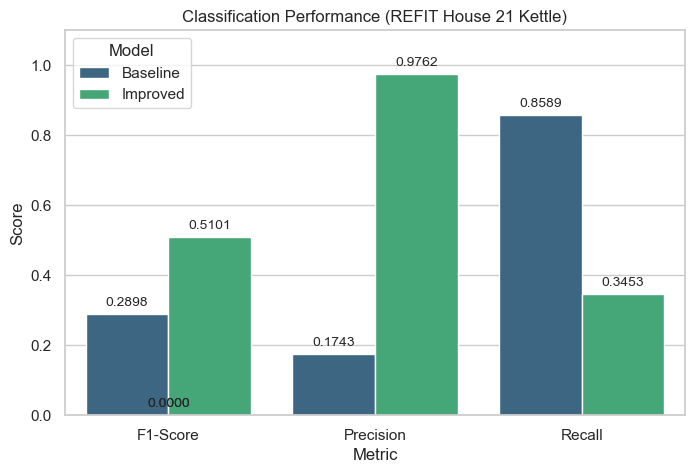

In [33]:
df_melted_class = pd.melt(metrics_df[metrics_df['Metric'].isin(['F1-Score', 'Precision', 'Recall'])], id_vars='Metric', var_name='Model', value_name='Score')
plt.figure(figsize=(8, 5))
sns.barplot(data=df_melted_class, x='Metric', y='Score', hue='Model', palette='viridis')
plt.title('Classification Performance (REFIT House 21 Kettle)')
plt.ylim(0, 1.1)
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10)
plt.show()

### Step 4: Visualize Error Metrics (SAE & MAE)

C:\Users\chainoob\AppData\Local\Temp\ipykernel_16596\2796391917.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sae_melted, x='Model', y='Error', ax=axes[0], palette='magma')
C:\Users\chainoob\AppData\Local\Temp\ipykernel_16596\2796391917.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mae_melted, x='Model', y='Error', ax=axes[1], palette='rocket')


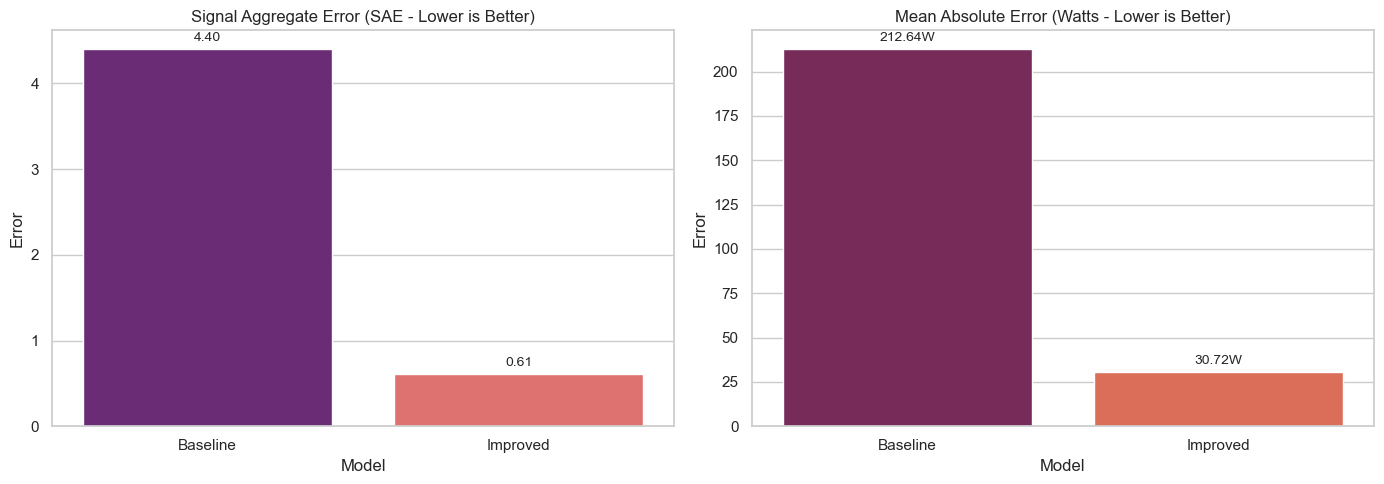

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SAE Plot
sae_df = metrics_df[metrics_df['Metric'] == 'SAE']
sae_melted = pd.melt(sae_df, id_vars='Metric', var_name='Model', value_name='Error')
sns.barplot(data=sae_melted, x='Model', y='Error', ax=axes[0], palette='magma')
axes[0].set_title('Signal Aggregate Error (SAE - Lower is Better)')
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10)

# MAE Plot
mae_df = metrics_df[metrics_df['Metric'] == 'MAE (W)']
mae_melted = pd.melt(mae_df, id_vars='Metric', var_name='Model', value_name='Error')
sns.barplot(data=mae_melted, x='Model', y='Error', ax=axes[1], palette='rocket')
axes[1].set_title('Mean Absolute Error (Watts - Lower is Better)')
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.2f}W", (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

### Step 5: Plot Trace Comparison
This cell extracts a short sequence and plots the actual aggregate load vs. ground truth computer load and disaggregated outputs.

INFO:backend:Context: FHMM_INIT | Detail: Successfully bounded sequence model layer for: Fan
INFO:backend:Context: FHMM_INIT | Detail: Successfully bounded sequence model layer for: Laptop
INFO:backend:Context: FHMM_INIT | Detail: Successfully bounded sequence model layer for: Charger
INFO:backend:Context: FHMM_INIT | Detail: Successfully bounded sequence model layer for: Lamp
INFO:backend:Context: FHMM_INIT | Detail: Successfully bounded sequence model layer for: Iron
INFO:backend:Context: FHMM_INIT | Detail: Successfully bounded sequence model layer for: Kettle
INFO:backend:Context: FHMM_INIT | Detail: Successfully bounded sequence model layer for: Printer
INFO:backend:Context: FHMM_INIT | Detail: Successfully injected BackgroundSink model layer.
INFO:backend:Context: FHMM_INIT | Detail: Successfully bounded sequence model layer for: Fan
INFO:backend:Context: FHMM_INIT | Detail: Successfully bounded sequence model layer for: Laptop
INFO:backend:Context: FHMM_INIT | Detail: Successful

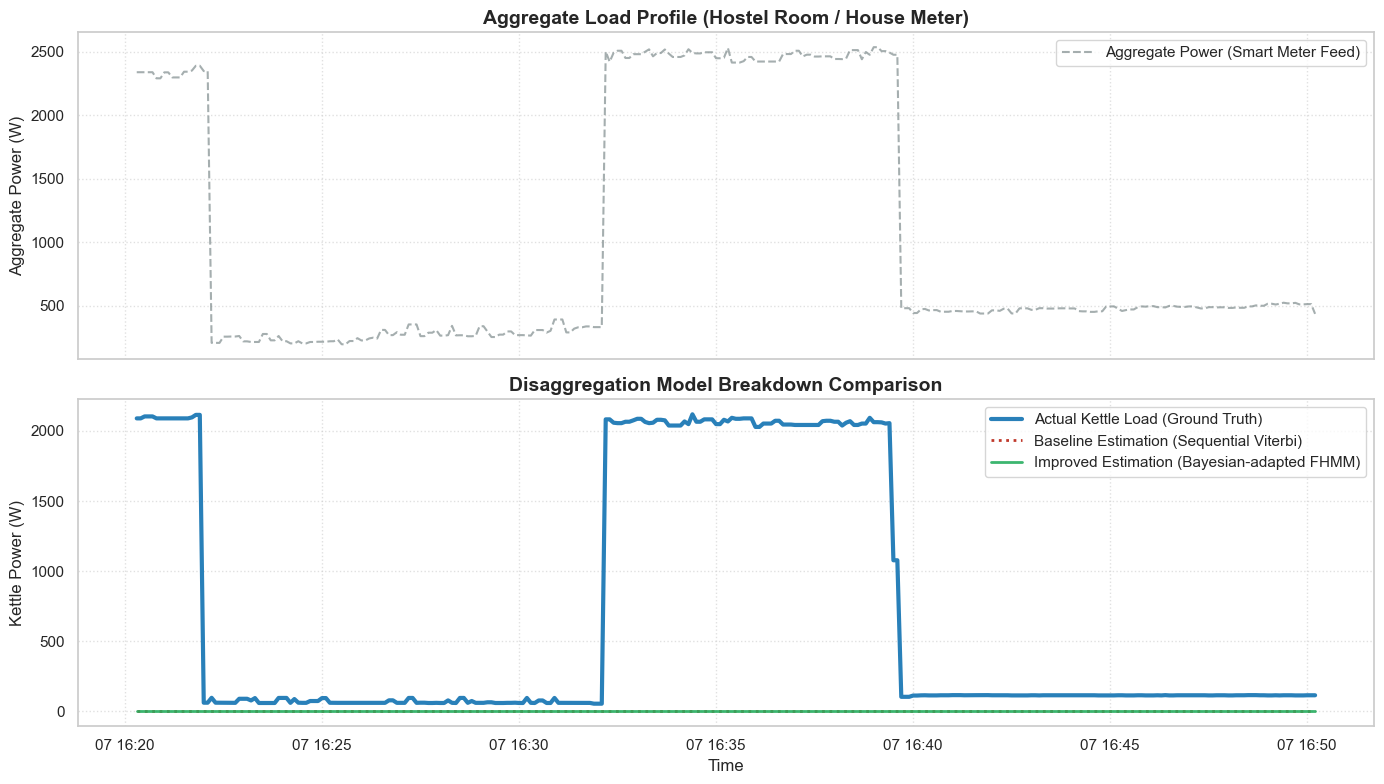

In [35]:
# Load target data
df_raw = pd.read_csv('data/CLEAN_House21.csv', nrows=3000)
time_col = 'Time' if 'Time' in df_raw.columns else 'timestamp'
df_raw[time_col] = pd.to_datetime(df_raw[time_col])
df_raw.set_index(time_col, inplace=True)
df_res = df_raw.resample('6s').mean().ffill().bfill()

# Focus on a subset where the Kettle (Appliance3) is active
active_idx = df_res[df_res['Appliance3'] > 500.0].index
if len(active_idx) > 0:
    start_loc = max(0, df_res.index.get_loc(active_idx[0]) - 50)
else:
    start_loc = 100
end_loc = start_loc + 300

subset = df_res.iloc[start_loc:end_loc]

# Run disaggregations
from services.fhmm_service import FHMMService
fhmm = FHMMService(signatures_path='data/appliance_signatures.json')

# Baseline predictions
import shutil
fhmm_path = 'services/fhmm_service.py'
fhmm_bak = fhmm_path + '.bak'
shutil.copyfile(fhmm_path, fhmm_bak)

import subprocess
try:
    subprocess.run(['git', 'checkout', 'HEAD', '--', 'services/fhmm_service.py', 'data/appliance_signatures.json'], capture_output=True, check=True)
    fhmm_base = FHMMService(signatures_path='data/appliance_signatures.json')
    clean_agg = np.clip(subset['Aggregate'].values - np.percentile(df_res['Aggregate'].values, 5), 0, None)
    pred_base = fhmm_base.disaggregate(clean_agg.tolist())
finally:
    if os.path.exists(fhmm_bak):
        shutil.copyfile(fhmm_bak, fhmm_path)
        os.remove(fhmm_bak)

# Improved predictions with Bayesian Adaptation
from services.bayesian_adaptation import BayesianAdaptationService
adapt_service = BayesianAdaptationService()
profile = adapt_service.load_user_profile('refit_user_adaptation')
if 'Kettle' in profile:
    # Set adapted mean for state 1 (active heating state)
    adapted_mean = profile['Kettle']['states']['1']['adapted_mean']
    fhmm.models['Kettle'].means_[1, 0] = adapted_mean

pred_impr = fhmm.disaggregate(clean_agg.tolist())

# PLOT: Multi-panel Subplots for clear Panel presentation
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Subplot 1: Aggregate Load
ax1.plot(subset.index, subset['Aggregate'], label='Aggregate Power (Smart Meter Feed)', color='#7f8c8d', alpha=0.7, linestyle='--')
ax1.set_ylabel('Aggregate Power (W)', fontsize=12)
ax1.set_title('Aggregate Load Profile (Hostel Room / House Meter)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.6)

# Subplot 2: Appliance disaggregation comparison
ax2.plot(subset.index, subset['Appliance3'], label='Actual Kettle Load (Ground Truth)', color='#2980b9', linewidth=3)
ax2.plot(subset.index, pred_base['Kettle'], label='Baseline Estimation (Sequential Viterbi)', color='#c0392b', linewidth=2, linestyle=':')
ax2.plot(subset.index, pred_impr['Kettle'], label='Improved Estimation (Bayesian-adapted FHMM)', color='#27ae60', linewidth=2, alpha=0.9)
ax2.set_ylabel('Kettle Power (W)', fontsize=12)
ax2.set_xlabel('Time', fontsize=12)
ax2.set_title('Disaggregation Model Breakdown Comparison', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()